# Quoridor AlphaZero — Colab training

Trains the Quoridor bot by self-play with checkpoints on Google Drive, so the run
survives Colab disconnects and GPU preemption.

**How to use**

1. `Runtime > Change runtime type > GPU` (T4 is fine).
2. `Runtime > Run all`.
3. After any crash or disconnect: just `Run all` again — training **resumes
   exactly** where it left off (same episode, optimizer state, replay buffer,
   RNG streams) from the checkpoint on Drive.

The game environment runs on the C++ engine (`quoridor/`) exposed through
pybind11 — a lockstep-verified, drop-in replacement for the pure-Python
reference env (see `alphazero/test_cpp_backend.py`).

In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow', tf.__version__)
print('GPU:', gpus[0].name if gpus else
      'NONE — enable one via Runtime > Change runtime type > GPU')

TensorFlow 2.20.0
GPU: /physical_device:GPU:0


In [3]:
!nvidia-smi

Tue Jul  7 23:00:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P0             30W /   70W |     383MiB /  15360MiB |     17%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1 — Google Drive

Checkpoints, network weights and training plots are written here, so they
persist across runtimes.

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2 — Code

In [5]:
import os

REPO = '/content/quoridor-bot'
if not os.path.exists(REPO):
    !git clone https://github.com/sihaowu1/quoridor-bot {REPO}
else:
    !git -C {REPO} pull --ff-only
%cd {REPO}

Already up to date.
/content/quoridor-bot


## 3 — Build the C++ engine

`quoridor/build_ext.py` compiles the pybind11 extension to
`alphazero/quoridor_engine.*.so` (on Colab it uses the preinstalled g++; no
zig needed here). The last line confirms the pipeline actually selected the
C++ backend — it must print `alphazero.quoridor_cpp`.

In [6]:
!pip install -q pybind11
!python quoridor/build_ext.py
!python -c "from alphazero.game_config import Quoridor; print('engine backend:', Quoridor.__module__)"

c++ -std=c++17 -O3 -DNDEBUG -fPIC -shared -fvisibility=hidden -I/usr/local/lib/python3.12/dist-packages/pybind11/include -I/usr/include/python3.12 /content/quoridor-bot/quoridor/quoridor.cpp /content/quoridor-bot/quoridor/bindings.cpp -o /content/quoridor-bot/alphazero/quoridor_engine.cpython-312-x86_64-linux-gnu.so
built alphazero/quoridor_engine.cpython-312-x86_64-linux-gnu.so
import smoke test passed
engine backend: alphazero.quoridor_cpp


## 4 — Cross-validate the C++ engine

Replays rule-targeted positions and hundreds of random games through both
backends in lockstep, asserting bit-identical observations, rewards, legal
actions and exceptions at every ply, then prints a speed comparison. Takes a
few minutes; skip it once you trust the build.

In [7]:
!python -m alphazero.test_cpp_backend --bench

_test_constructor_invariants: ok
_test_jump_positions: ok
_test_wall_rule_positions: ok
_test_wins_both_players: ok
_test_illegal_and_exception_parity: ok
_test_truncation_parity: ok
_test_clone_independence: ok
_test_random_lockstep_5x5: ok
_test_random_lockstep_jump_heavy: ok
_test_random_lockstep_9x9: ok
all tests passed
5x5: 100 random games, 8101 plies | python 0.51s, cpp 0.13s (3.9x faster, 61k plies/s)
9x9: 20 random games, 8581 plies | python 3.49s, cpp 0.25s (13.7x faster, 34k plies/s)


Validate that the CNN works properly. Expected output is (2, 1) and (2, 140)

In [8]:
!python -c "import numpy as np; from alphazero.mcts import policy_v, policy_p; from alphazero.game_config import GAME_OBS, GAME_ACTIONS; o=np.zeros((2,GAME_OBS)); print(policy_v(o).shape, policy_p(o).shape)"

2026-07-07 23:01:25.790980: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1783465285.792382   19748 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13377 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
(2, 1) (2, 140)


## 5 — Configure the run

| env variable          | meaning                                             |
|-----------------------|-----------------------------------------------------|
| `AZ_CHECKPOINT_DIR`   | Drive folder for checkpoints, weights and plots     |
| `AZ_EPISODES`         | total self-play episodes for the run                |
| `AZ_CHECKPOINT_EVERY` | save frequency in episodes (1 = safest)             |
| `AZ_BACKEND`          | `cpp` = require the C++ engine (fail loudly)        |
| `AZ_PARALLEL_GAMES`   | self-play games per lock-step batch (GPU batch size)|

`AZ_PARALLEL_GAMES` is the main throughput knob: bigger batches amortize the
per-simulation network-call overhead almost for free on a T4. The trade-off
is that checkpoints are only written **between** batches, so a bigger batch
widens the work lost to a Colab preemption. Use the in-batch heartbeat
(`s/ply`) to compare settings: throughput ≈ active games ÷ s/ply.

The board size / wall count live in `alphazero/game_config.py`
(currently the full 9×9 game with 10 walls).

In [9]:
import os

CKPT_DIR = '/content/drive/MyDrive/quoridor-checkpoints'
os.environ['AZ_CHECKPOINT_DIR'] = CKPT_DIR
os.environ['AZ_EPISODES'] = '2000'
os.environ['AZ_CHECKPOINT_EVERY'] = '1'
os.environ['AZ_BACKEND'] = 'cpp'
os.environ['AZ_PARALLEL_GAMES'] = '128'

os.makedirs(CKPT_DIR, exist_ok=True)
state = sorted(f for f in os.listdir(CKPT_DIR) if f.endswith('_train_state.pkl'))
print('checkpoint dir:', CKPT_DIR)
print('will resume from:', state[0] if state else 'nothing yet — fresh run')

checkpoint dir: /content/drive/MyDrive/quoridor-checkpoints
will resume from: Quoridor_train_state.pkl


## 6 — Train

Safe to interrupt and re-run at any time: the driver saves the complete
training state atomically after every episode and auto-resumes from the
latest readable checkpoint (a `.bak` fallback covers a save that was cut
off mid-write).

In [10]:
!python -m alphazero.run

2026-07-07 23:01:39.779983: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1783465299.781488   19852 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13377 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
resumed from checkpoint: episode 1536, 50000 buffered positions
  self-play: ply 10, 128/128 games running, 514s elapsed (51.4s/ply)
  self-play: ply 20, 128/128 games running, 705s elapsed (35.2s/ply)
  self-play: ply 30, 39/128 games running, 795s elapsed (26.5s/ply)
  self-play: ply 40, 4/128 games running, 831s elapsed (20.8s/ply)
  self-play: ply 50, 2/128 games running, 850s elapsed (17.0s/ply)
  self-play: ply 60, 2/128 games running, 873s elapsed (14.5s/ply)
  self-play: ply 70, 2/128 games running, 891s elapsed (12.7s/ply)
  self-play: ply 80, 2/12

## 7 — Progress plots

Refreshed on Drive at every evaluation, so this cell can be re-run while
training is going (or from a different machine mounting the same Drive).

game_length.png


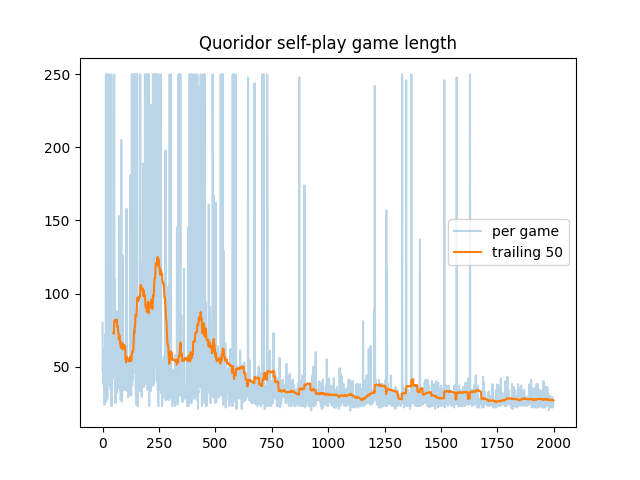

policy_loss.png


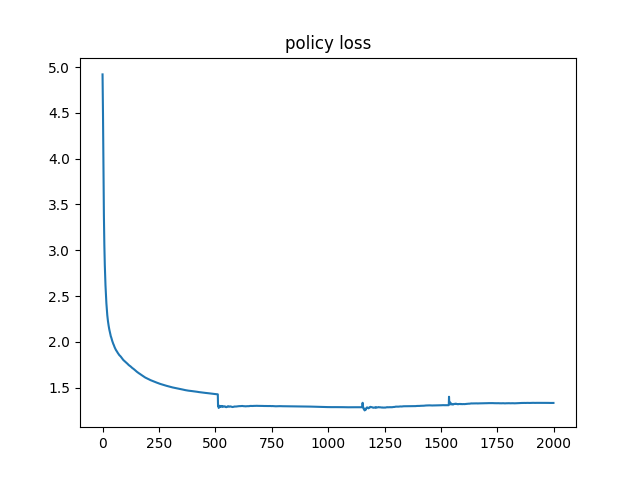

value_loss.png


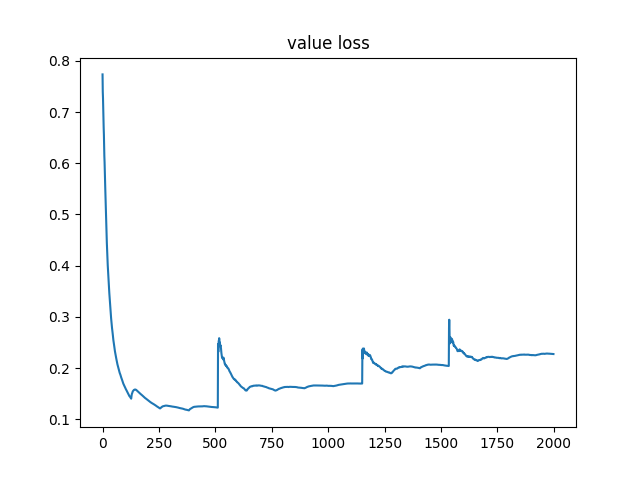

win_rate.png


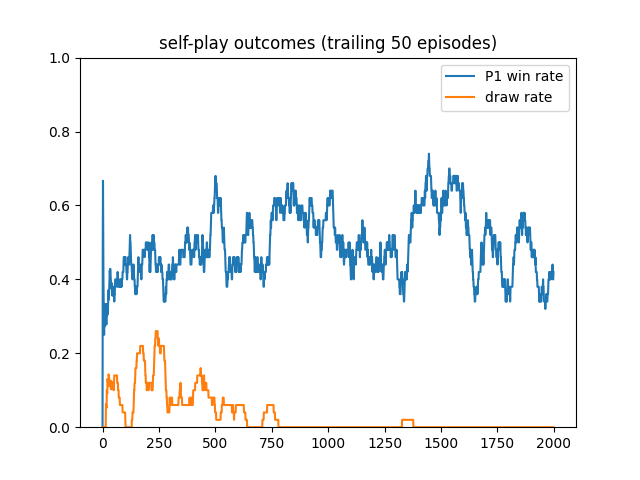

In [11]:
import glob
import os

from IPython.display import Image, display

pngs = sorted(glob.glob(os.path.join(os.environ['AZ_CHECKPOINT_DIR'], '*.png')))
if not pngs:
    print('no plots yet — they appear after the first evaluation')
for png in pngs:
    print(os.path.basename(png))
    display(Image(filename=png))